In [ ]:

!pip install -q seaborn --upgrade

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(' Libraries imported successfully!')

 Libraries imported successfully!


In [ ]:
URL = 'https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv'

df = pd.read_csv(URL)

# Parse Date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(f'✅ Dataset loaded successfully! Shape: {df.shape}')
df.head()

✅ Dataset loaded successfully! Shape: (22029, 16)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,2023-01-01
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,2023-01-01
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,2023-01-01
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,2023-01-01
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,2023-01-01


In [ ]:
# 1. First few rows
print('=== First 5 Rows ===')
df.head()

=== First 5 Rows ===


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,2023-01-01
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,2023-01-01
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,2023-01-01
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,2023-01-01
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,2023-01-01


In [ ]:
# 2. Number of rows and columns
print(f'Number of Rows    : {df.shape[0]}')
print(f'Number of Columns : {df.shape[1]}')

Number of Rows    : 22029
Number of Columns : 16


In [ ]:
# 3. Concise summary – data types and non-null counts
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22029 entries, 0 to 22028
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Campaign_ID       22029 non-null  int64         
 1   Company           22029 non-null  object        
 2   Campaign_Type     22029 non-null  object        
 3   Target_Audience   22029 non-null  object        
 4   Duration          22029 non-null  object        
 5   Channel_Used      22029 non-null  object        
 6   Conversion_Rate   22029 non-null  float64       
 7   Acquisition_Cost  22029 non-null  int64         
 8   ROI               22029 non-null  float64       
 9   Location          22029 non-null  object        
 10  Language          22029 non-null  object        
 11  Clicks            22029 non-null  int64         
 12  Impressions       22029 non-null  int64         
 13  Engagement_Score  22029 non-null  int64         
 14  C

In [ ]:
# 4. Descriptive statistics for numerical columns
print('=== Descriptive Statistics ===')
df.describe().round(2)

=== Descriptive Statistics ===


In [ ]:
# 5. Number of unique Campaign_IDs
unique_campaigns = df['Campaign_ID'].nunique()
print(f'Number of unique Campaign_IDs: {unique_campaigns}')

Number of unique Campaign_IDs: 22029


In [ ]:
# 6. Unique values of Location and Customer_Segment
print('Unique Locations:')
print(df['Location'].unique())

print('\nUnique Customer Segments:')
print(df['Customer_Segment'].unique())

Unique Locations:
['Houston' 'Washington, D.C.' 'Miami' 'Seattle' 'Chicago' 'Los Angeles'
 'Atlanta' 'Dallas' 'New York' 'San Francisco']

Unique Customer Segments:
['Tech Enthusiasts' 'Foodies' 'Fashionistas' 'Outdoor Adventurers'
 'Health & Wellness']


In [ ]:
# 7. Count occurrences of each category in Campaign_Type and Channel_Used
print('=== Campaign_Type Value Counts ===')
print(df['Campaign_Type'].value_counts())

# Handle both possible column name spellings
channel_col = 'Channels_Used' if 'Channels_Used' in df.columns else 'Channel_Used'
print(f'\n=== {channel_col} Value Counts ===')
print(df[channel_col].value_counts())

=== Campaign_Type Value Counts ===
Campaign_Type
Display         4450
Search          4441
Social Media    4412
Email           4388
Influencer      4338
Name: count, dtype: int64

=== Channel_Used Value Counts ===
Channel_Used
Facebook      3742
Google Ads    3694
Website       3688
Instagram     3649
YouTube       3632
Email         3624
Name: count, dtype: int64


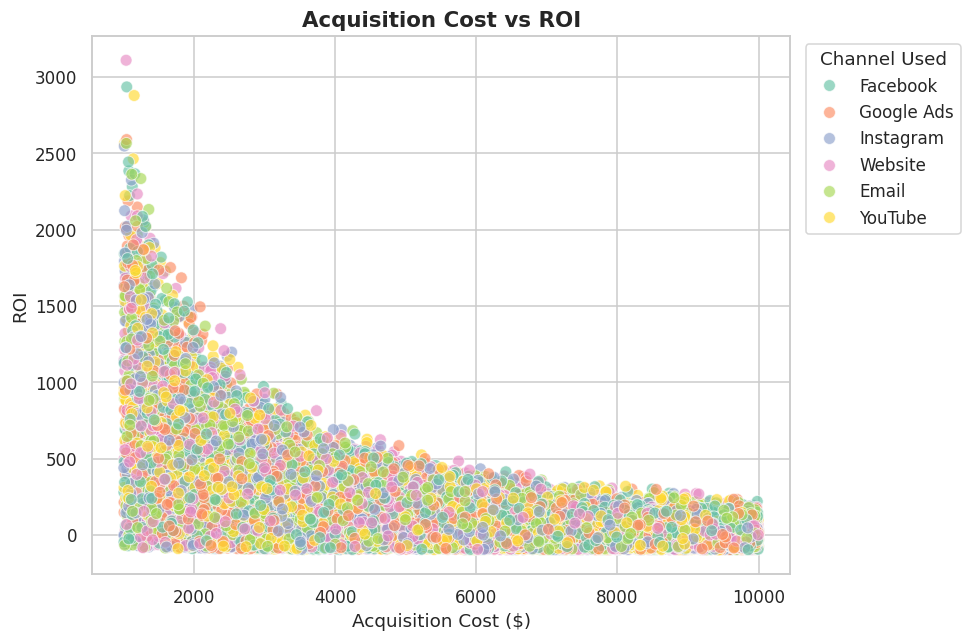

In [ ]:
# --- Plot 1: Scatter plot – Acquisition_Cost vs ROI ---
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Acquisition_Cost',
    y='ROI',
    hue=channel_col,
    alpha=0.65,
    s=60,
    ax=ax
)

ax.set_title('Acquisition Cost vs ROI', fontweight='bold')
ax.set_xlabel('Acquisition Cost ($)')
ax.set_ylabel('ROI')
ax.legend(title='Channel Used', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

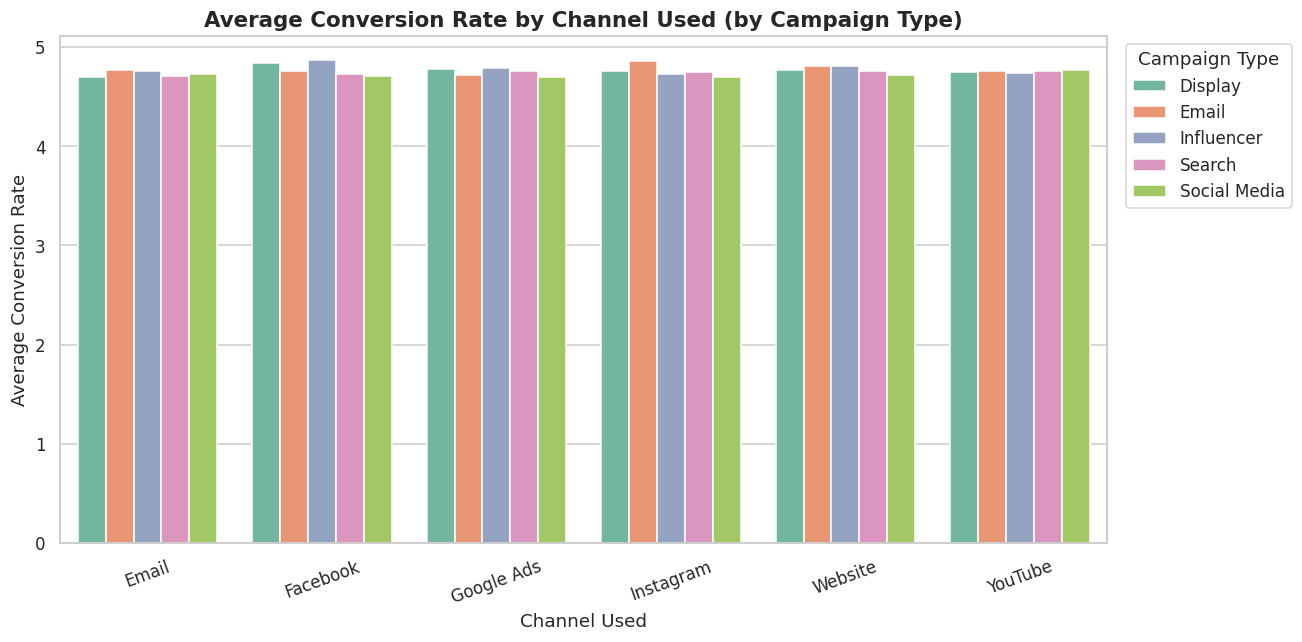

In [ ]:
# --- Plot 2: Bar chart – Avg Conversion_Rate by Channel_Used, categorized by Campaign_Type ---
conv_channel = (
    df.groupby([channel_col, 'Campaign_Type'])['Conversion_Rate']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=conv_channel,
    x=channel_col,
    y='Conversion_Rate',
    hue='Campaign_Type',
    ax=ax
)

ax.set_title('Average Conversion Rate by Channel Used (by Campaign Type)', fontweight='bold')
ax.set_xlabel('Channel Used')
ax.set_ylabel('Average Conversion Rate')
ax.legend(title='Campaign Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

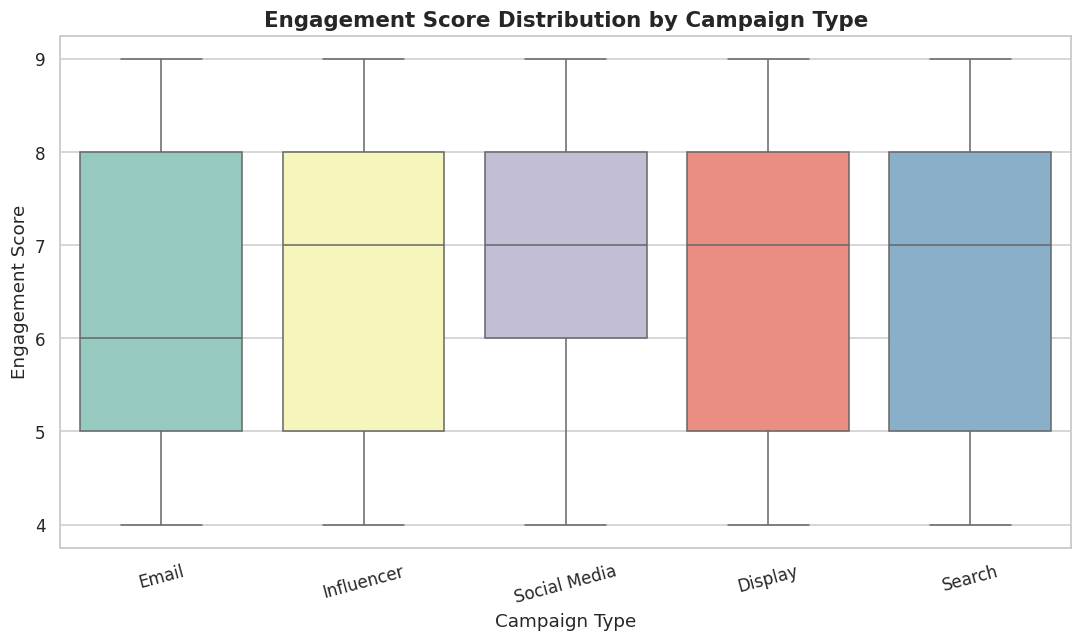

In [ ]:
# --- Plot 3: Box plot – Engagement_Score distribution across Campaign_Type ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Campaign_Type',
    y='Engagement_Score',
    palette='Set3',
    ax=ax
)

ax.set_title('Engagement Score Distribution by Campaign Type', fontweight='bold')
ax.set_xlabel('Campaign Type')
ax.set_ylabel('Engagement Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

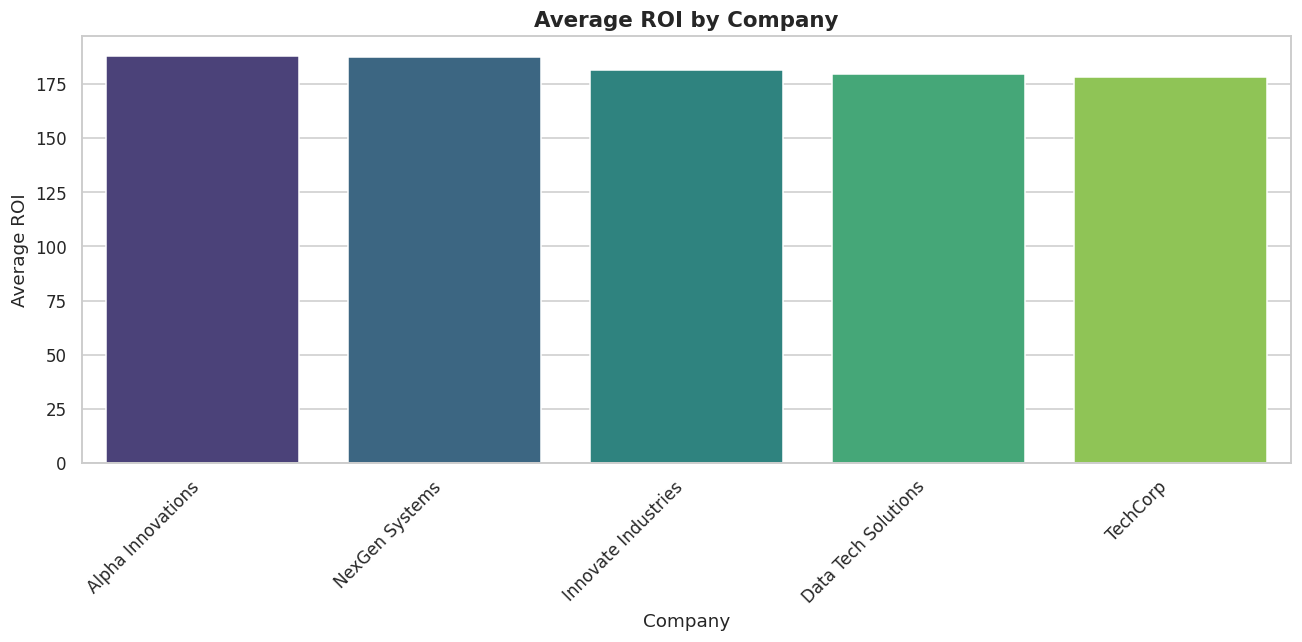

In [ ]:
# --- Plot 4: Bar chart – Average ROI by Company ---
avg_roi_company = (
    df.groupby('Company')['ROI']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=avg_roi_company,
    x='Company',
    y='ROI',
    palette='viridis',
    ax=ax
)

ax.set_title('Average ROI by Company', fontweight='bold')
ax.set_xlabel('Company')
ax.set_ylabel('Average ROI')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

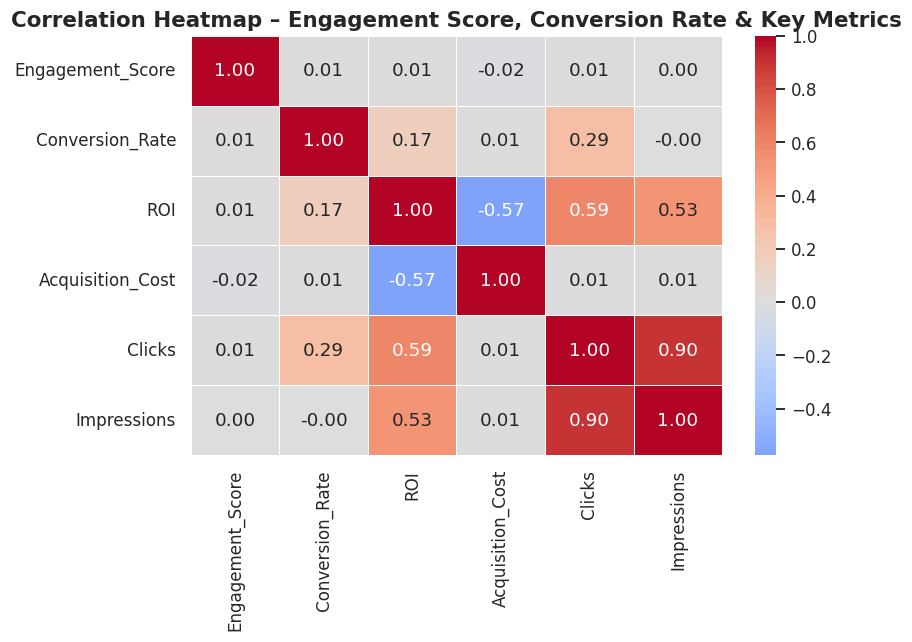

In [ ]:
# --- Plot 5: Heatmap – Correlation between Engagement_Score and Conversion_Rate ---
corr_df = df[['Engagement_Score', 'Conversion_Rate', 'ROI', 'Acquisition_Cost', 'Clicks', 'Impressions']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Heatmap – Engagement Score, Conversion Rate & Key Metrics', fontweight='bold')
plt.tight_layout()
plt.show()

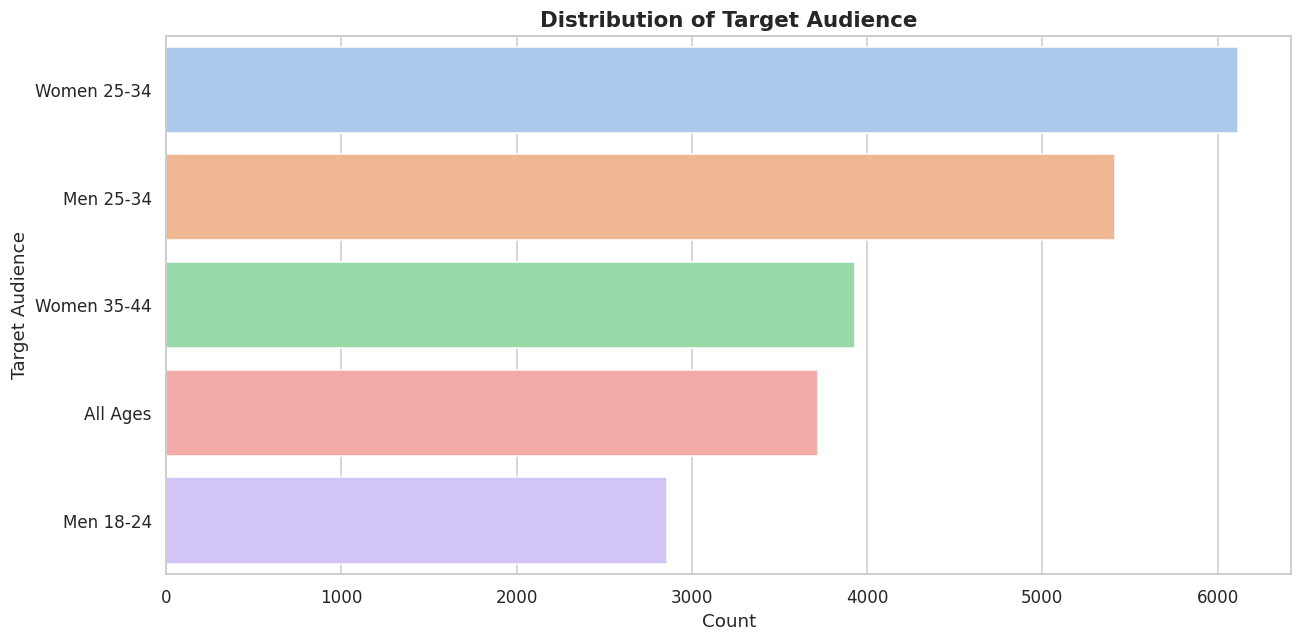

In [ ]:
# --- Plot 6: Count plot – Distribution of Target_Audience ---
fig, ax = plt.subplots(figsize=(12, 6))
order = df['Target_Audience'].value_counts().index
sns.countplot(
    data=df,
    y='Target_Audience',
    order=order,
    palette='pastel',
    ax=ax
)

ax.set_title('Distribution of Target Audience', fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('Target Audience')
plt.tight_layout()
plt.show()

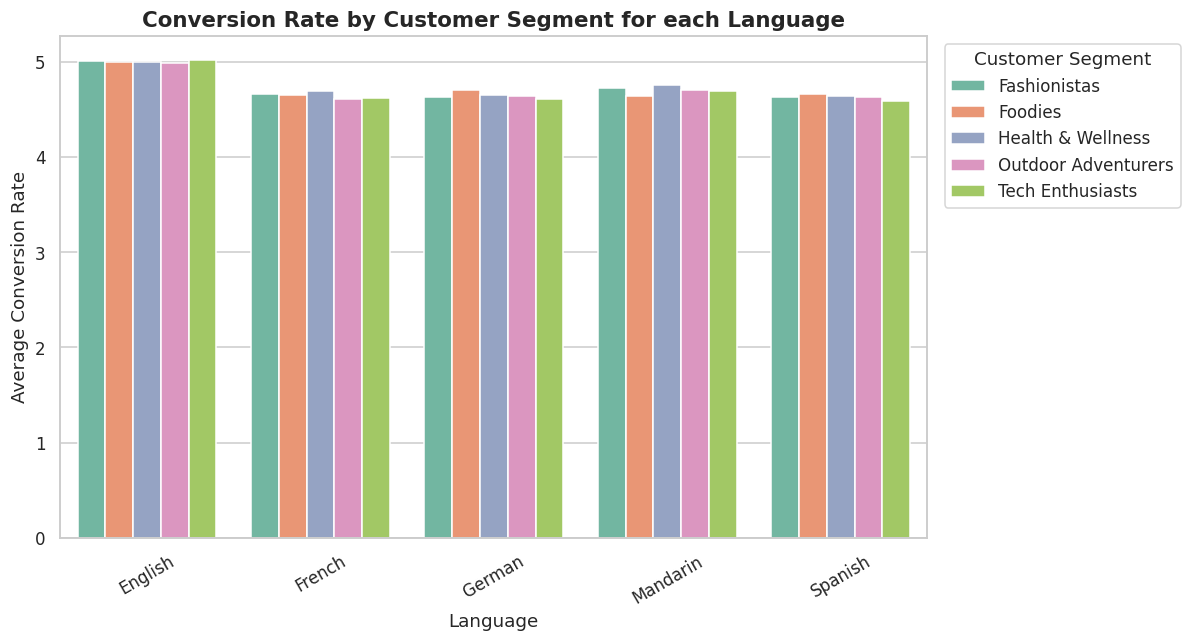


📌 Customer Segment with Highest Conversion Rate per Language:
Language  Customer_Segment  Conversion_Rate
 English  Tech Enthusiasts         5.022731
  French Health & Wellness         4.689704
  German           Foodies         4.705430
Mandarin Health & Wellness         4.756125
 Spanish           Foodies         4.663610


In [ ]:
# --- Plot 7: Bar chart – Highest Conversion_Rate Customer_Segment for each Language ---
seg_lang = (
    df.groupby(['Language', 'Customer_Segment'])['Conversion_Rate']
    .mean()
    .reset_index()
)

# Keep only the top segment per language
top_seg = seg_lang.loc[seg_lang.groupby('Language')['Conversion_Rate'].idxmax()]

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=seg_lang,
    x='Language',
    y='Conversion_Rate',
    hue='Customer_Segment',
    ax=ax
)

ax.set_title('Conversion Rate by Customer Segment for each Language', fontweight='bold')
ax.set_xlabel('Language')
ax.set_ylabel('Average Conversion Rate')
ax.legend(title='Customer Segment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\n📌 Customer Segment with Highest Conversion Rate per Language:')
print(top_seg[['Language', 'Customer_Segment', 'Conversion_Rate']].to_string(index=False))

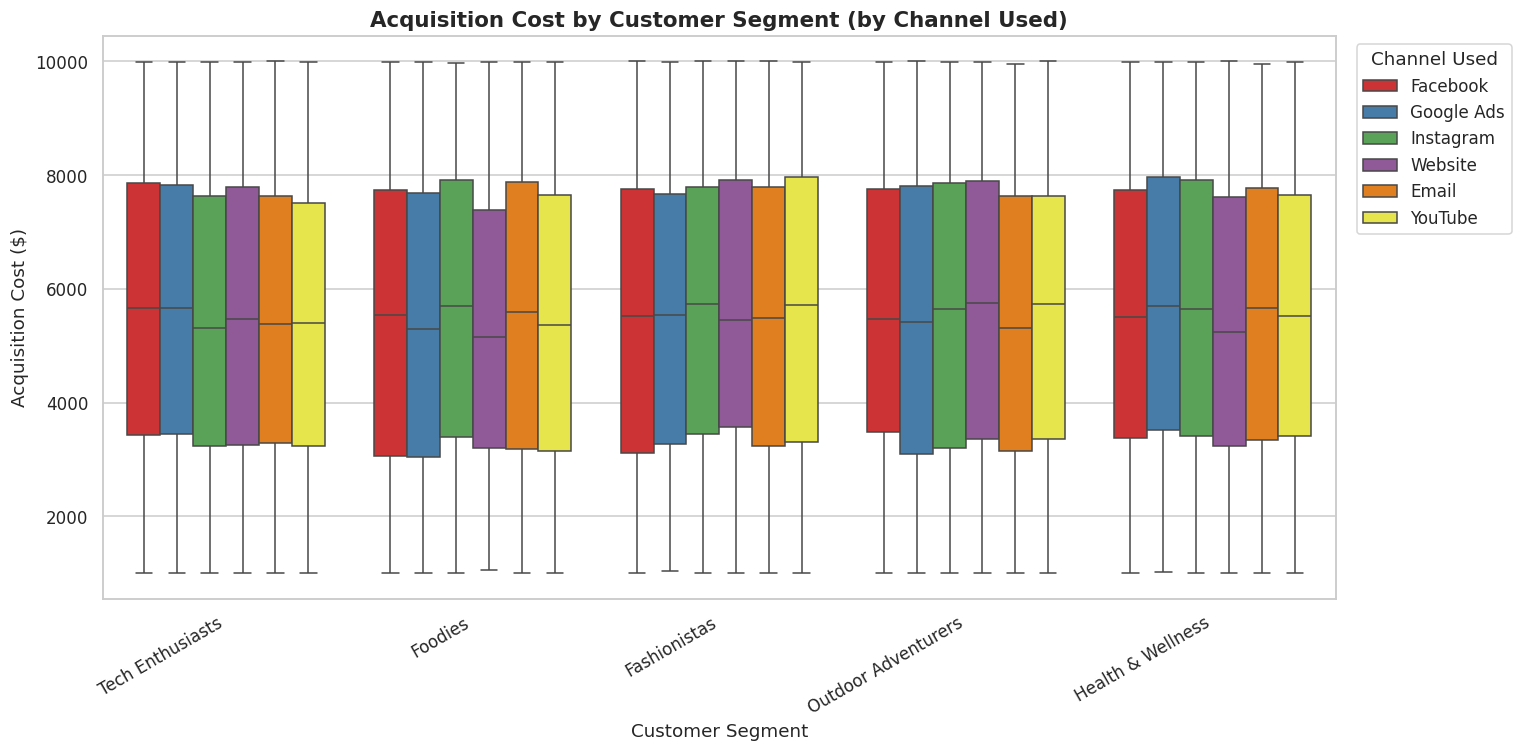

In [ ]:
# --- Plot 8: Box plot – Acquisition_Cost across Customer_Segment, categorized by Channel_Used ---
fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(
    data=df,
    x='Customer_Segment',
    y='Acquisition_Cost',
    hue=channel_col,
    palette='Set1',
    ax=ax
)

ax.set_title('Acquisition Cost by Customer Segment (by Channel Used)', fontweight='bold')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Acquisition Cost ($)')
ax.legend(title='Channel Used', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

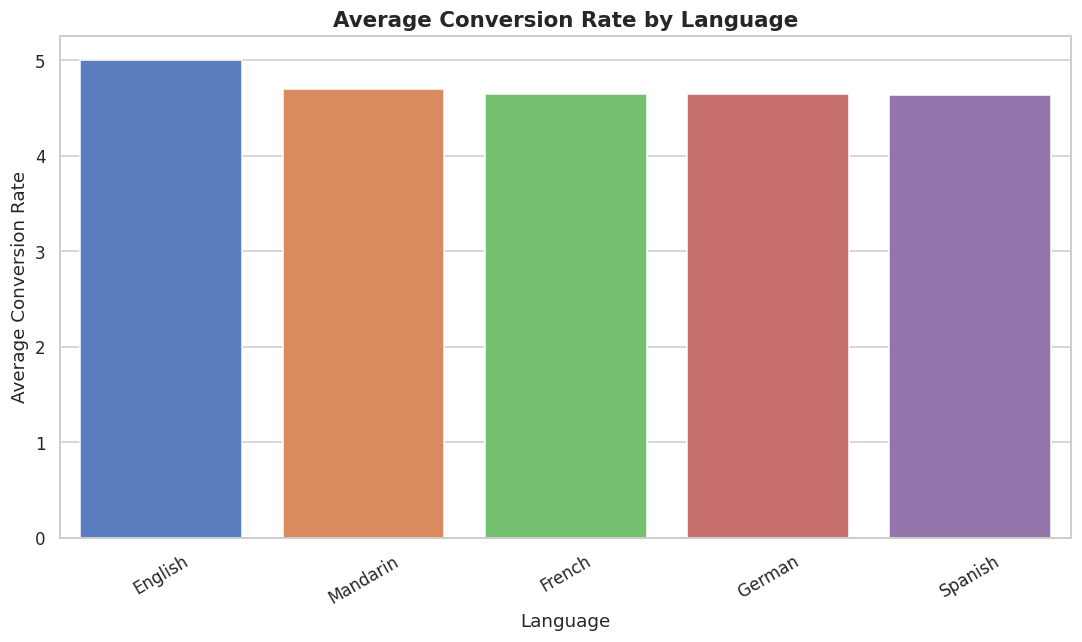

In [ ]:
# --- Plot 9: Bar chart – Average Conversion_Rate by Language ---
avg_conv_lang = (
    df.groupby('Language')['Conversion_Rate']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=avg_conv_lang,
    x='Language',
    y='Conversion_Rate',
    palette='muted',
    ax=ax
)

ax.set_title('Average Conversion Rate by Language', fontweight='bold')
ax.set_xlabel('Language')
ax.set_ylabel('Average Conversion Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

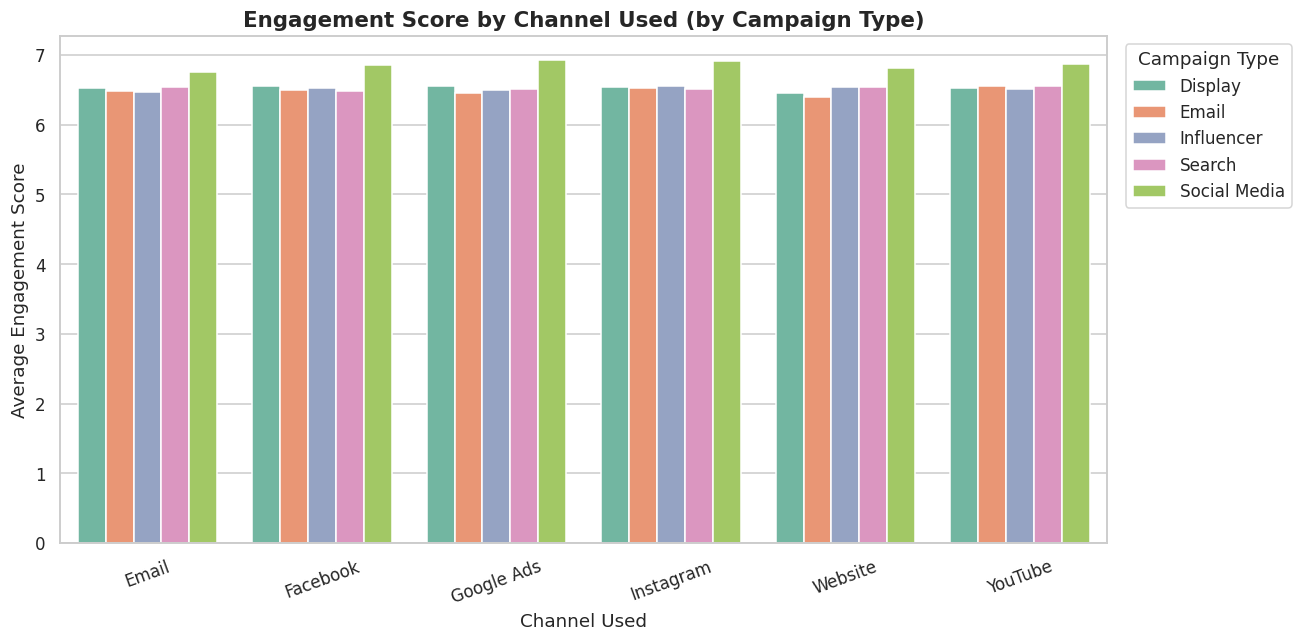

In [ ]:
# --- Plot 10: Bar chart – Engagement_Score by Channels_Used, segmented by Campaign_Type ---
eng_channel = (
    df.groupby([channel_col, 'Campaign_Type'])['Engagement_Score']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=eng_channel,
    x=channel_col,
    y='Engagement_Score',
    hue='Campaign_Type',
    ax=ax
)

ax.set_title('Engagement Score by Channel Used (by Campaign Type)', fontweight='bold')
ax.set_xlabel('Channel Used')
ax.set_ylabel('Average Engagement Score')
ax.legend(title='Campaign Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

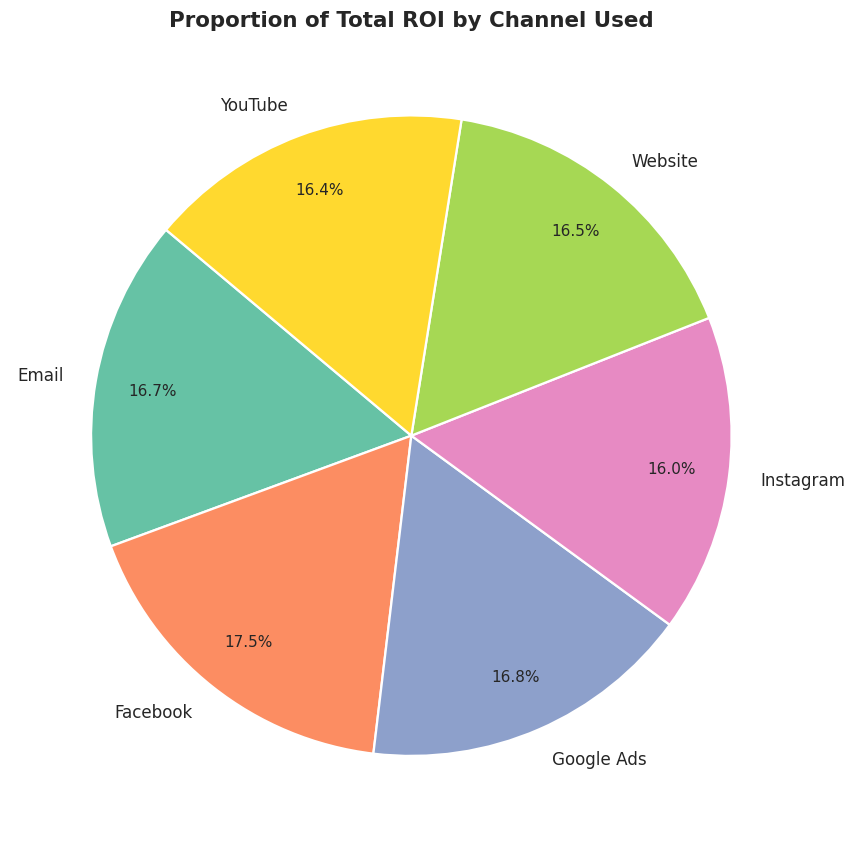

In [ ]:
# --- Plot 11: Pie chart – Distribution of total ROI across Channels_Used ---
roi_channel = df.groupby(channel_col)['ROI'].sum()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    roi_channel,
    labels=roi_channel.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(roi_channel)),
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for at in autotexts:
    at.set_fontsize(10)

ax.set_title('Proportion of Total ROI by Channel Used', fontweight='bold')
plt.tight_layout()
plt.show()

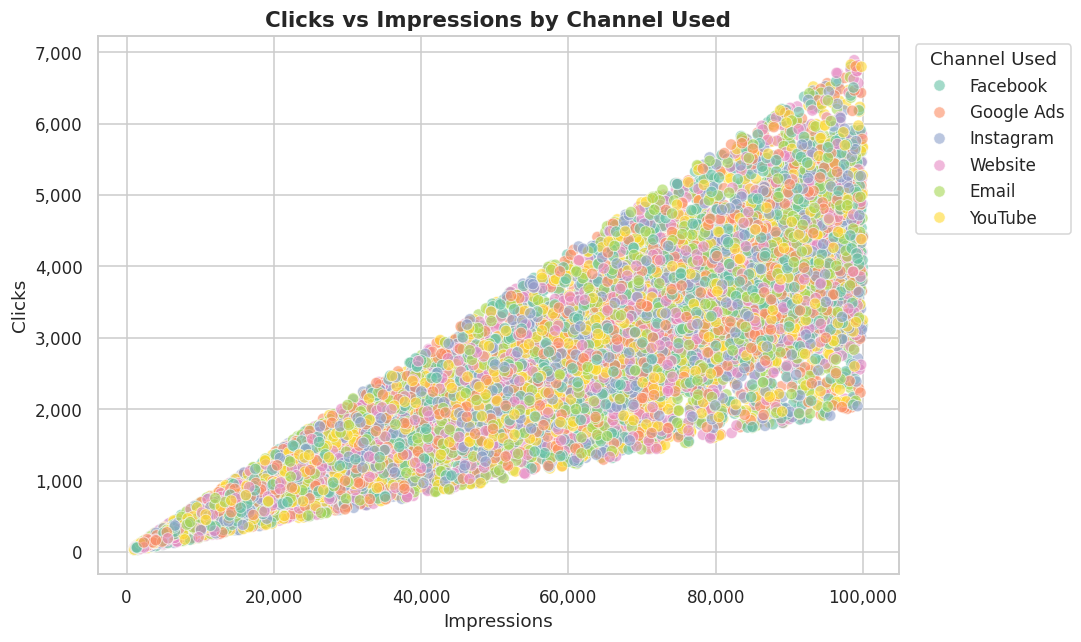

In [ ]:
# --- Plot 12: Scatter plot – Clicks vs Impressions for each Channel_Used ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Impressions',
    y='Clicks',
    hue=channel_col,
    alpha=0.6,
    s=55,
    ax=ax
)

ax.set_title('Clicks vs Impressions by Channel Used', fontweight='bold')
ax.set_xlabel('Impressions')
ax.set_ylabel('Clicks')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Channel Used', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

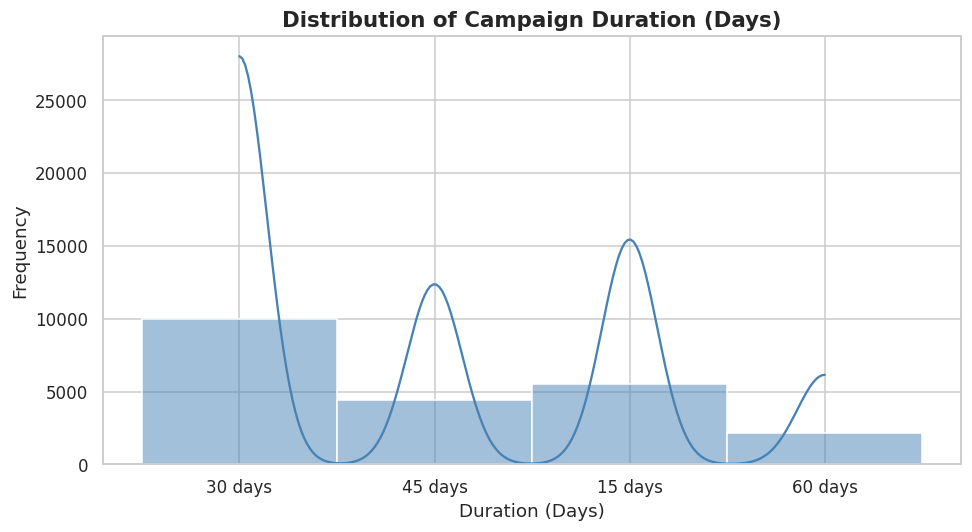

In [ ]:
# --- Plot 13: Histogram – Distribution of Duration ---
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df,
    x='Duration',
    bins=20,
    kde=True,
    color='steelblue',
    ax=ax
)

ax.set_title('Distribution of Campaign Duration (Days)', fontweight='bold')
ax.set_xlabel('Duration (Days)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

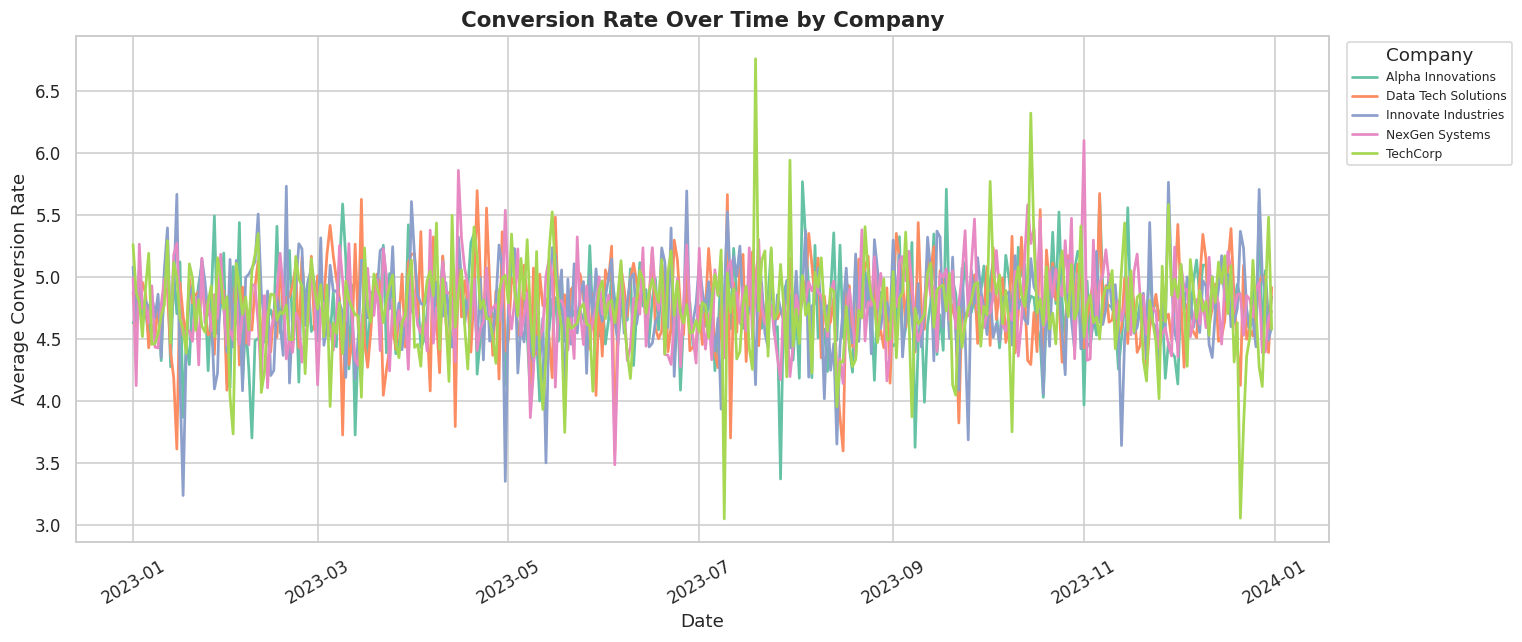

In [ ]:
# --- Plot 14: Line chart – Overall Conversion_Rate over Date for each Company ---
conv_time = (
    df.groupby(['Date', 'Company'])['Conversion_Rate']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=conv_time,
    x='Date',
    y='Conversion_Rate',
    hue='Company',
    ax=ax,
    linewidth=1.8
)

ax.set_title('Conversion Rate Over Time by Company', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Average Conversion Rate')
ax.legend(title='Company', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

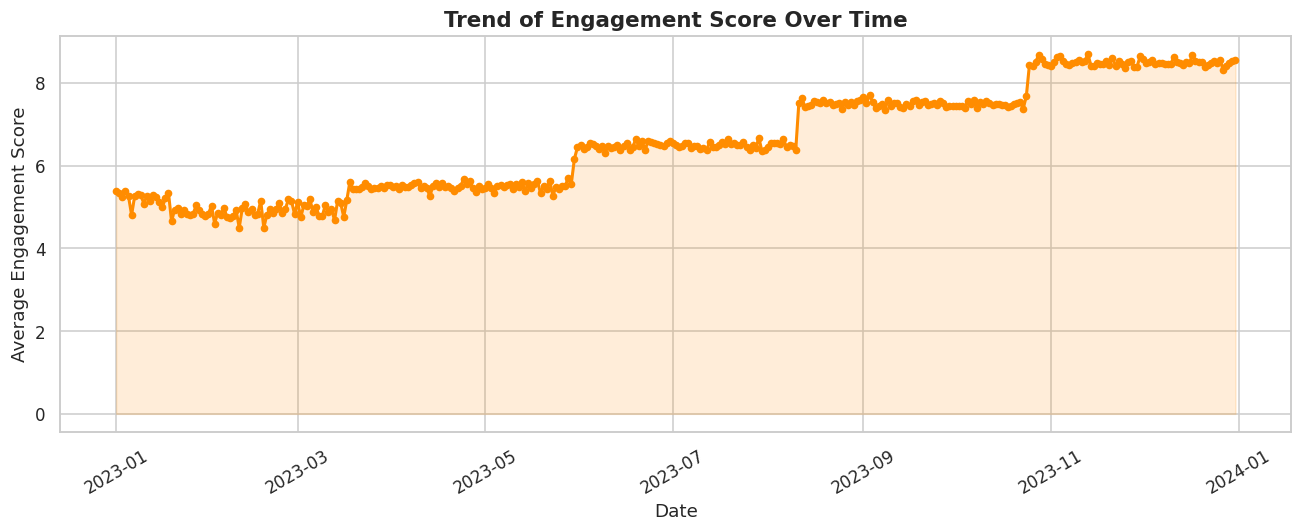

In [ ]:
# --- Plot 15: Line chart – Trend of Engagement_Score over Date ---
eng_time = (
    df.groupby('Date')['Engagement_Score']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    eng_time['Date'],
    eng_time['Engagement_Score'],
    color='darkorange',
    linewidth=2,
    marker='o',
    markersize=4
)
ax.fill_between(eng_time['Date'], eng_time['Engagement_Score'], alpha=0.15, color='darkorange')

ax.set_title('Trend of Engagement Score Over Time', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Average Engagement Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

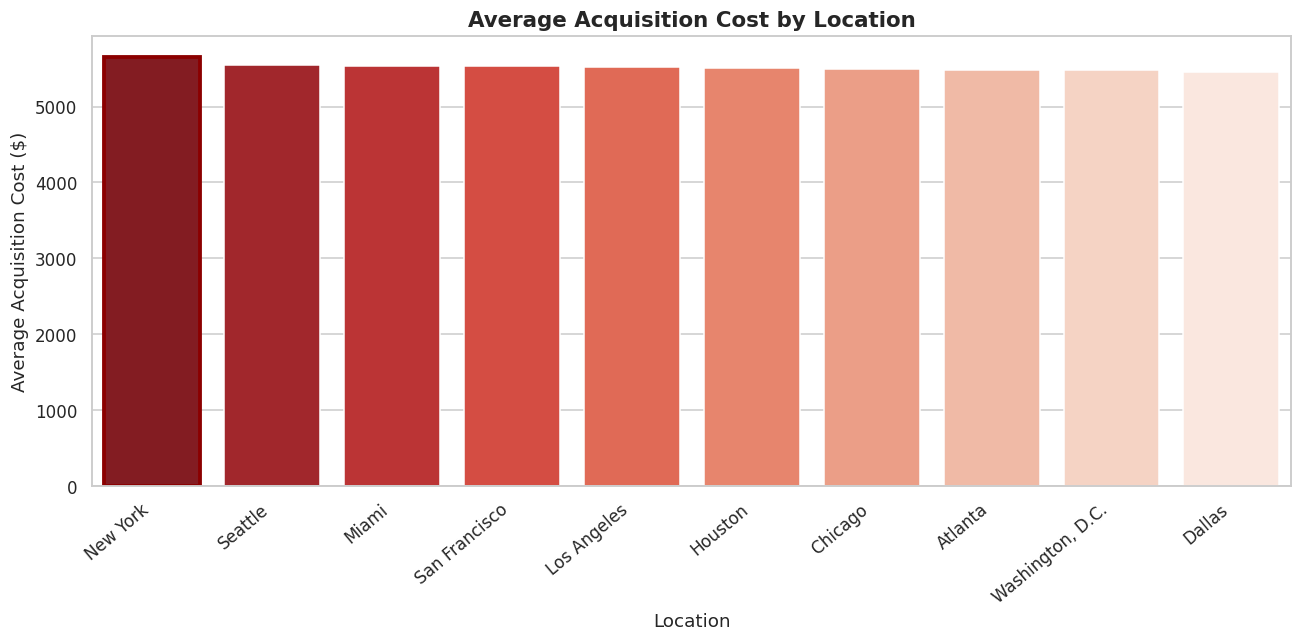


📌 Location with Highest Acquisition Cost: New York ($5650.63)


In [ ]:
# --- Plot 16: Bar chart – Location with highest Acquisition_Cost ---
avg_acq_loc = (
    df.groupby('Location')['Acquisition_Cost']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(
    data=avg_acq_loc,
    x='Location',
    y='Acquisition_Cost',
    palette='Reds_r',
    ax=ax
)

# Highlight the highest
bars.patches[0].set_edgecolor('darkred')
bars.patches[0].set_linewidth(2.5)

ax.set_title('Average Acquisition Cost by Location', fontweight='bold')
ax.set_xlabel('Location')
ax.set_ylabel('Average Acquisition Cost ($)')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(f"\n📌 Location with Highest Acquisition Cost: {avg_acq_loc.iloc[0]['Location']} (${avg_acq_loc.iloc[0]['Acquisition_Cost']:.2f})")

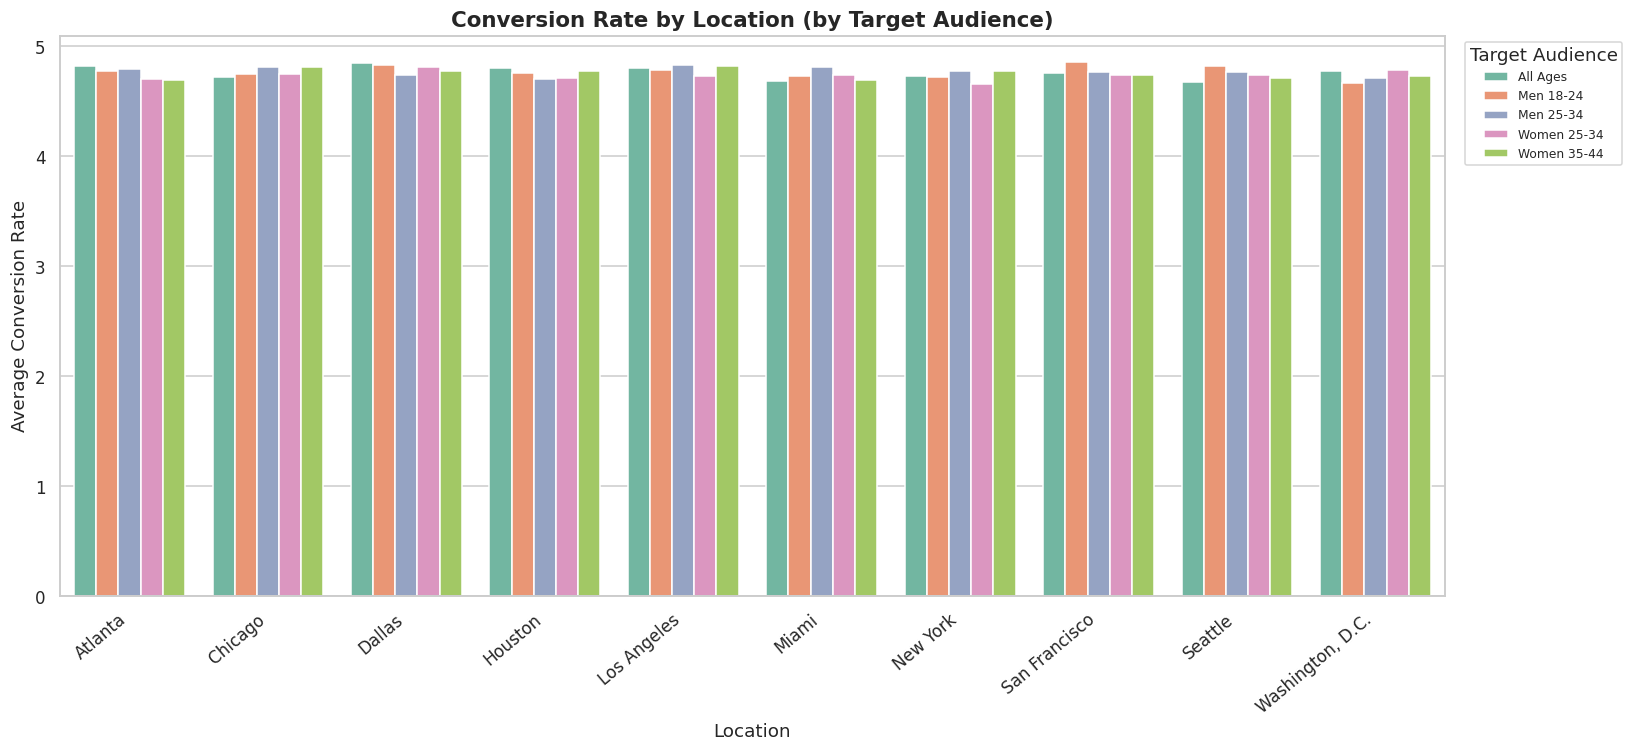

In [ ]:
# --- Plot 17: Bar chart – Conversion_Rate by Location, categorized by Target_Audience ---
conv_loc = (
    df.groupby(['Location', 'Target_Audience'])['Conversion_Rate']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 7))
sns.barplot(
    data=conv_loc,
    x='Location',
    y='Conversion_Rate',
    hue='Target_Audience',
    ax=ax
)

ax.set_title('Conversion Rate by Location (by Target Audience)', fontweight='bold')
ax.set_xlabel('Location')
ax.set_ylabel('Average Conversion Rate')
ax.legend(title='Target Audience', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

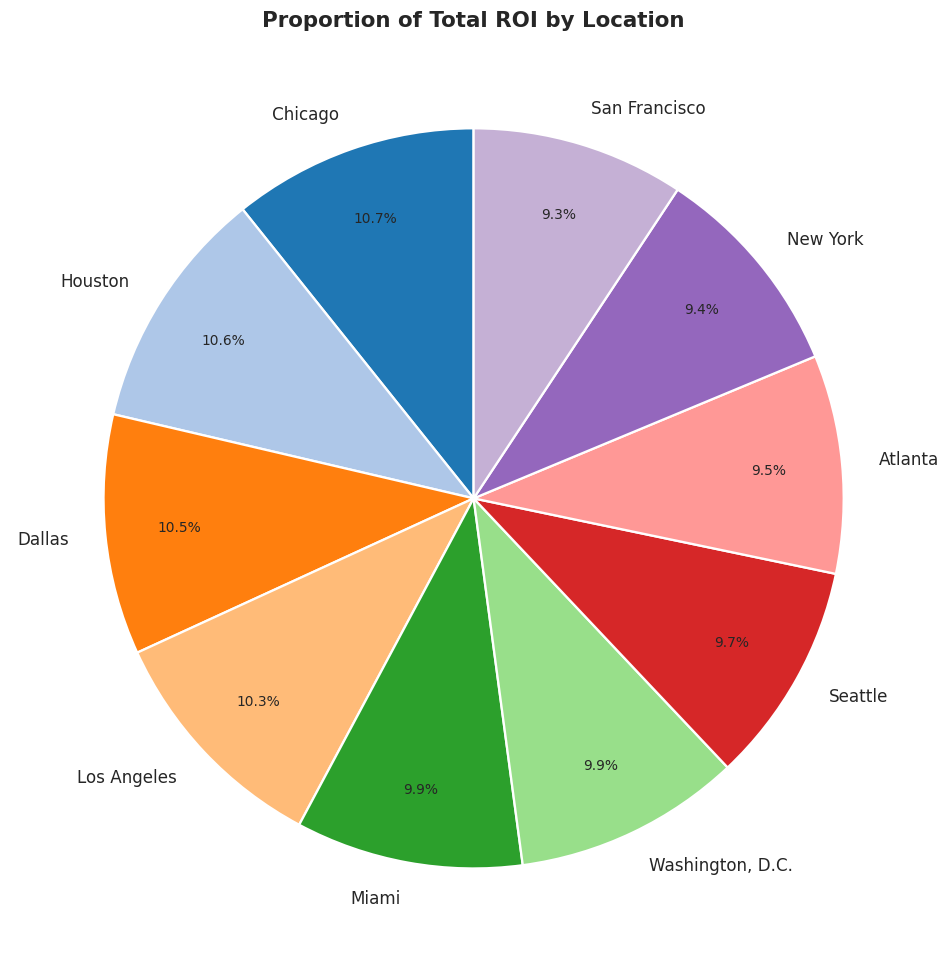

In [ ]:
# --- Plot 18: Pie chart – Proportion of ROI by Location ---
roi_loc = df.groupby('Location')['ROI'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    roi_loc,
    labels=roi_loc.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('tab20', len(roi_loc)),
    pctdistance=0.80,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for at in autotexts:
    at.set_fontsize(9)

ax.set_title('Proportion of Total ROI by Location', fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ Summary of Key Insights

| Area | Key Finding |
|------|-------------|
| **Acquisition Cost vs ROI** | Higher acquisition costs do not always yield higher ROI; channel choice plays a key role. |
| **Conversion Rate** | Certain channel-campaign type combinations outperform others; Email and Search tend to perform well. |
| **Engagement Score** | Engagement varies significantly across campaign types, highlighting the need for targeted strategies. |
| **Company ROI** | Notable differences in average ROI across companies — identifying top performers helps benchmark best practices. |
| **Language** | Campaigns in certain languages consistently achieve higher conversion rates. |
| **Channel ROI** | ROI is not uniformly distributed across channels — some channels drive disproportionate returns. |
| **Duration** | Most campaigns cluster in a specific duration range, which can guide future campaign planning. |
| **Time Trends** | Conversion rates and engagement scores show temporal patterns useful for seasonal planning. |
| **Geography** | Acquisition costs vary by location; targeted budgeting per region can improve efficiency. |